In [129]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score

from sklearn.metrics import f1_score

In [92]:
df=pd.read_csv("Rainfall.csv")
df.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [93]:
df.describe()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,365.000000,365.000000
mean,15.756831,1013.742623,26.191257,23.747268,21.894536,19.989071,80.177596,71.128415,4.419399,101.506849,21.536986
std,8.823592,6.414776,5.978343,5.632813,5.594153,5.997021,10.062470,21.798012,3.934398,81.723724,10.069712
min,1.000000,998.500000,7.100000,4.900000,3.100000,-0.400000,36.000000,0.000000,0.000000,10.000000,4.400000
25%,8.000000,1008.500000,21.200000,18.825000,17.125000,16.125000,75.000000,58.000000,0.500000,40.000000,13.700000
50%,16.000000,1013.000000,27.750000,25.450000,23.700000,21.950000,80.500000,80.000000,3.500000,70.000000,20.500000
75%,23.000000,1018.100000,31.200000,28.600000,26.575000,25.000000,87.000000,88.000000,8.200000,190.000000,27.900000
max,31.000000,1034.600000,36.300000,32.400000,30.000000,26.700000,98.000000,100.000000,12.100000,350.000000,59.500000


In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    str    
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), str(1)
memory usage: 34.4 KB


In [95]:
df.isnull().sum().sort_values()

day                       0
pressure                  0
maxtemp                   0
temparature               0
mintemp                   0
dewpoint                  0
humidity                  0
cloud                     0
rainfall                  0
sunshine                  0
         winddirection    1
windspeed                 1
dtype: int64

In [96]:
df.columns

Index(['day', 'pressure ', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity ', 'cloud ', 'rainfall', 'sunshine', '         winddirection',
       'windspeed'],
      dtype='str')

In [97]:
df.rename(str.strip,axis="columns",inplace=True)

In [98]:
df.columns


Index(['day', 'pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection',
       'windspeed'],
      dtype='str')

In [99]:
df.dropna(subset=['winddirection'],inplace=True)

In [100]:
df.dropna(subset=['windspeed'],inplace=True)

In [101]:
df.isnull().sum()

day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
rainfall         0
sunshine         0
winddirection    0
windspeed        0
dtype: int64

In [102]:
df.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [103]:
df['rainfall'].value_counts()

rainfall
yes    248
no     117
Name: count, dtype: int64

<Axes: xlabel='rainfall', ylabel='count'>

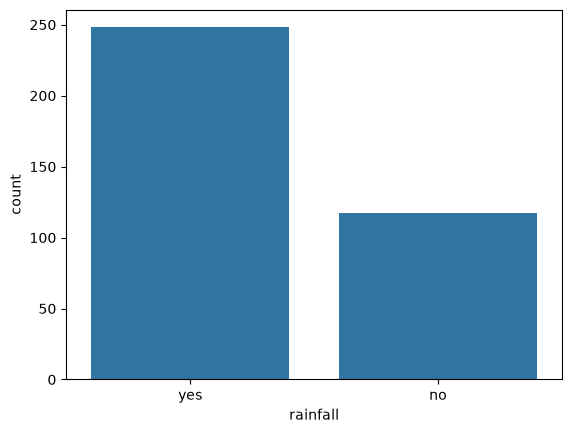

In [104]:
sns.countplot(data=df,x='rainfall')

In [105]:
df.groupby('rainfall').mean()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
rainfall,,,,,,,,,,,
no,15.623932,1014.576923,27.070940,24.053846,21.957265,18.766667,73.000000,51.256410,7.586325,103.076923,19.275214
yes,15.846774,1013.381452,25.754032,23.584677,21.845968,20.542742,83.540323,80.471774,2.916935,100.766129,22.604032


In [106]:
df.drop(columns="day",inplace=True)

In [107]:
df.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [108]:
df.columns

Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed'],
      dtype='str')

In [109]:
continuous_values=['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud',  'sunshine', 'winddirection', 'windspeed']

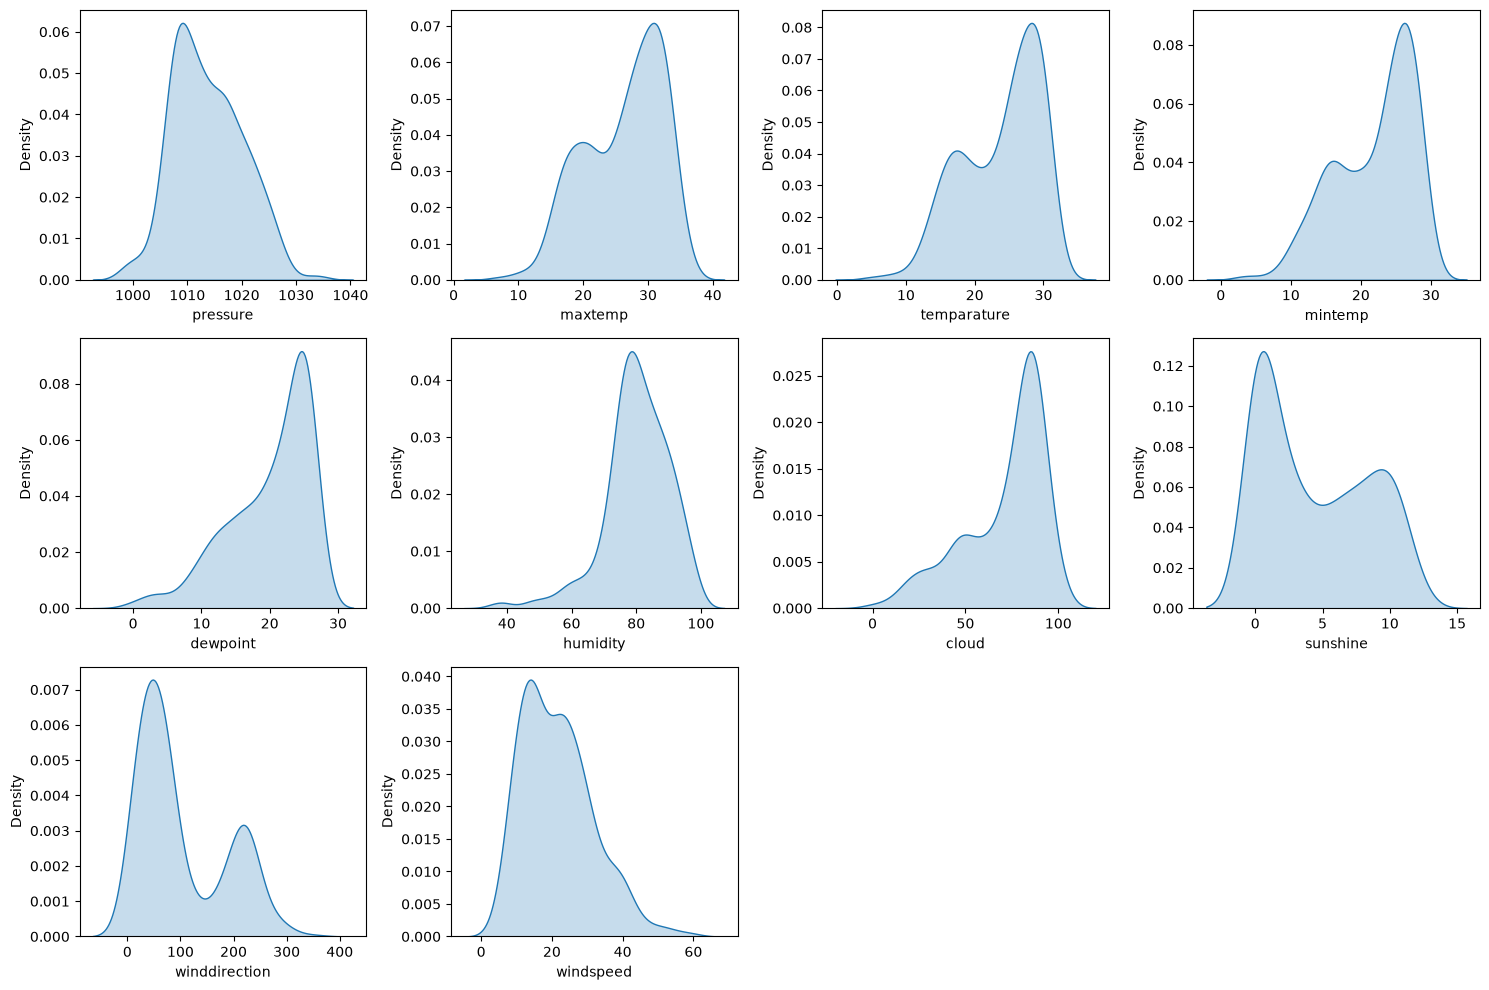

In [110]:
plt.figure(figsize=(15, 10))
for i,cols in enumerate(continuous_values):
    plt.subplot(3,4,i+1)
    sns.kdeplot(df[cols],fill=True)

plt.tight_layout()
plt.show()

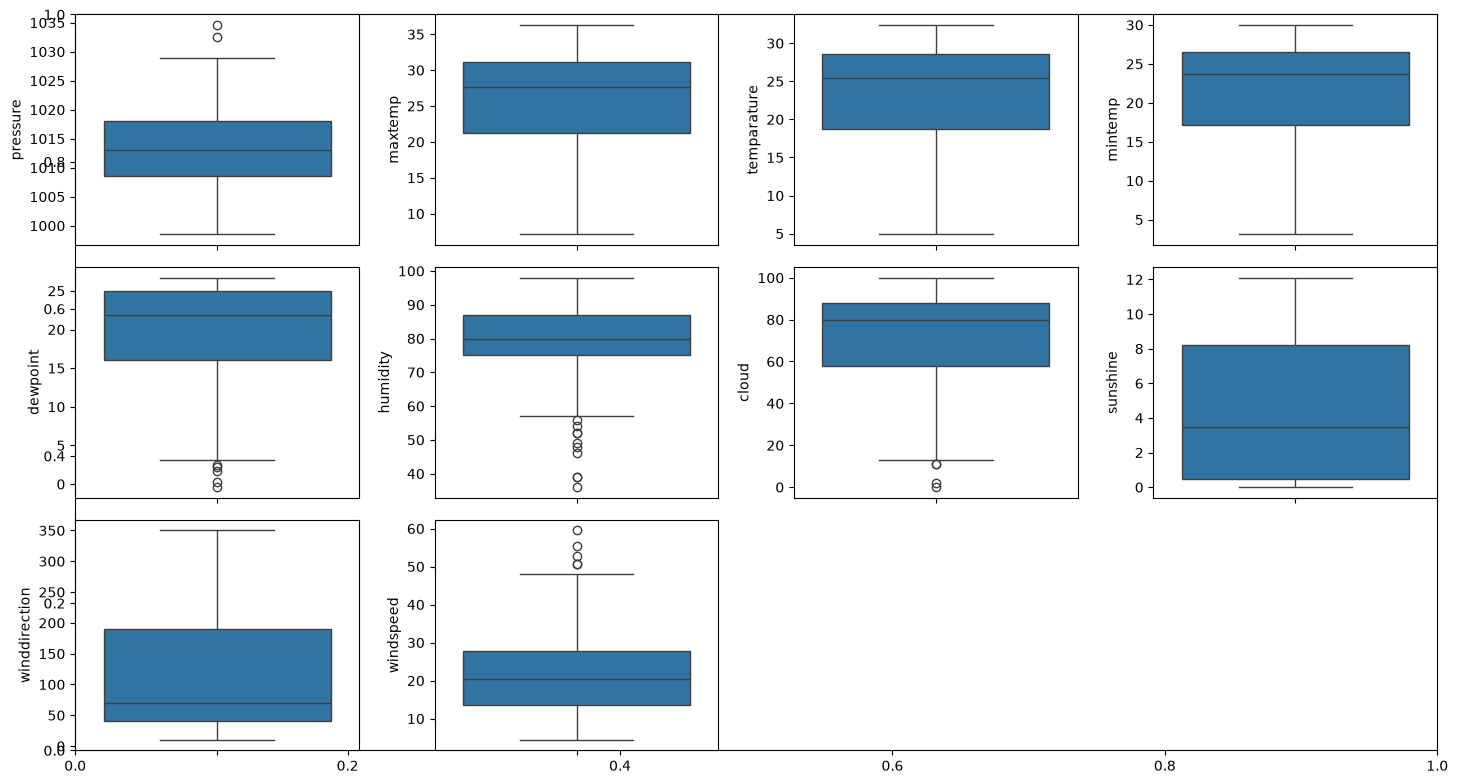

In [111]:
plt.subplots(figsize=(15,8))

for i, col in enumerate(continuous_values):
  plt.subplot(3,4, i + 1)
  sns.boxplot(df[col])
plt.tight_layout()
plt.show()

In [112]:
df['rainfall']=df['rainfall'].replace({"yes":1,"no":0})
df["rainfall"] = df["rainfall"].astype(int)

<Axes: >

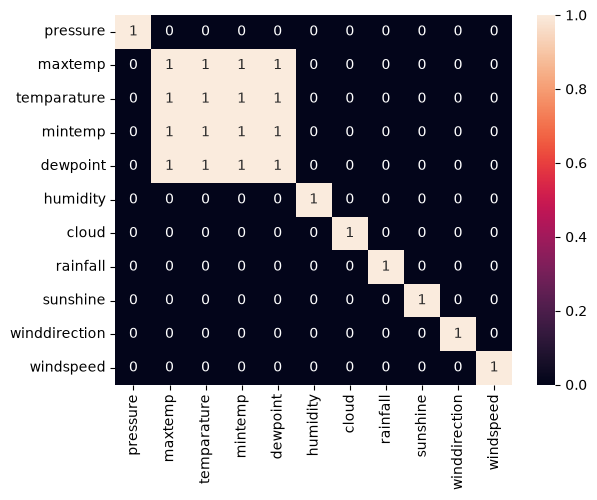

In [113]:
sns.heatmap(df.corr(numeric_only=True)>0.8,annot=True)

In [114]:
df.drop(['maxtemp', 'mintemp'], axis=1, inplace=True)

In [115]:
X=df.drop("rainfall",axis=1)
y=df['rainfall']

In [116]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)

In [117]:
scaler=StandardScaler()

In [118]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [119]:
result=[]

In [120]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM (RBF Kernel)": SVC(probability=True)
}

In [121]:
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    acc=accuracy_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    result.append({
        "model":model,
        "name":name,
        "f1_score":round(f1,4),
        "accuracy":round(acc,4)
    })

In [123]:
result

[{'model': LogisticRegression(),
  'name': 'Logistic Regression',
  'f1_score': 0.8319,
  'accuracy': 0.7397},
 {'model': KNeighborsClassifier(),
  'name': 'KNN',
  'f1_score': 0.8421,
  'accuracy': 0.7534},
 {'model': GaussianNB(),
  'name': 'Naive Bayes',
  'f1_score': 0.8257,
  'accuracy': 0.7397},
 {'model': DecisionTreeClassifier(),
  'name': 'Decision Tree',
  'f1_score': 0.8036,
  'accuracy': 0.6986},
 {'model': SVC(probability=True),
  'name': 'SVM (RBF Kernel)',
  'f1_score': 0.8246,
  'accuracy': 0.726}]

In [128]:
from sklearn.model_selection import train_test_split, GridSearchCV

param_grid = {
    'n_neighbors': np.arange(1,31),
     'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}
knn=KNeighborsClassifier()
# Step 5: Initialize GridSearchCV (using 5-Fold cross-validation)
grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Step 6: Fit the grid search on training data
grid_search.fit(X_train, y_train)

# Step 7: View the best parameters and evaluate
best_lr = grid_search.best_estimator_
print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_) 

Best parameters found: {'metric': 'manhattan', 'n_neighbors': np.int64(7), 'weights': 'uniform'}
Best cross-validation score: 0.8490940970192871


In [131]:
scores = cross_val_score(best_lr,X_train,y_train, cv=5,scoring="accuracy")
print("CV scores",scores)
print("Mean:", scores.mean(), "Std:", scores.std())

CV scores [0.89830508 0.86440678 0.86206897 0.75862069 0.86206897]
Mean: 0.8490940970192871 Std: 0.04728283288436329


In [135]:
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier, StackingClassifier
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# ── 2. TRAIN EACH MODEL (this defines ada, bag, gb, xgb, stack) ──

ensemble_models = {
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Bagging": BaggingClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    ),
    "Stacking": StackingClassifier(
        estimators=[
            ("knn", KNeighborsClassifier()),
            ("nb", GaussianNB()),
            ("svm", SVC(probability=True))
        ],
        final_estimator=KNeighborsClassifier(),
        cv=5
    )
}

results = []

for name, model in ensemble_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

pd.DataFrame(results)

,Model,Accuracy,F1 Score
0,AdaBoost,0.726027,0.827586
1,Bagging,0.753425,0.842105
2,Gradient Boosting,0.753425,0.839286
3,XGBoost,0.712329,0.814159
4,Stacking,0.794521,0.864865
